66 parquet files
797 full discharges, capacity 2.00~3.02 Ah (SOH按3.0Ah: 67%~101%)


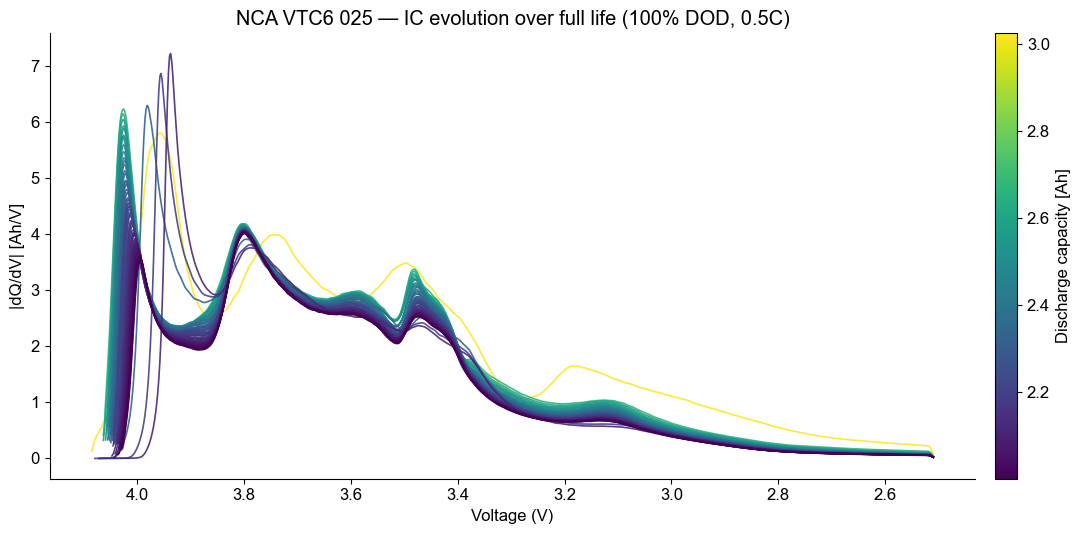

~3.45V (graphite?): 峰高~容量 相关 r=0.974
~3.6V: 峰高~容量 相关 r=0.848
~3.8V (NCA?): 峰高~容量 相关 r=0.450


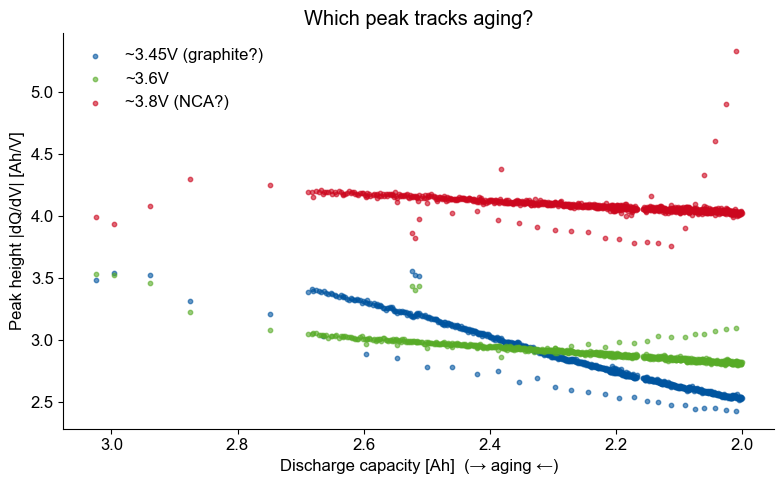

In [4]:
# ================================================================
# NCA VTC6 025: 全生命周期 IC 演化 + 逐峰高度追踪
# 目的: 找出哪个峰随老化单调变化 → 定NCA侧锚点
# 前提: fs, OPTS, TS 已定义
# ================================================================
import numpy as np, pandas as pd, pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter1d

DV_GRID=0.002; SIGMA=2; MIN_SEG=10
BASE="projects/j8005-metabatt/Metabatt/VTC/METABatt_Sony_Murata_18650VTC6_025"

files=[f for f in sorted(fs.ls(BASE)) if f.endswith('.parquet')]
print(f"{len(files)} parquet files")

curves=[]     # (cap_Ah, vgrid, IC)
for f in files:
    with fs.open(f) as fh:
        d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom']).to_pandas()
    d['Zeit']=TS(d['Zeit'])
    I=d['Strom'].values
    m=I<-1.0
    diff=np.diff(m.astype(int))
    st=np.where(diff==1)[0]+1; en=np.where(diff==-1)[0]+1
    if m[0]: st=np.r_[0,st]
    if m[-1]: en=np.r_[en,len(d)]
    for s,e in zip(st,en):
        if e-s<MIN_SEG: continue
        seg=d.iloc[s:e]
        V=seg['Spannung'].values
        i0=np.argmax(V<V[0]-0.015)                    # 掐起始IR瞬态
        if i0>0 and e-s-i0>=MIN_SEG:
            seg=seg.iloc[i0:]; V=seg['Spannung'].values
        t=(seg['Zeit']-seg['Zeit'].iloc[0]).dt.total_seconds().values
        Q=np.cumsum(np.abs(seg['Strom'].values)*np.diff(t,prepend=t[0])/3600.0)
        if Q[-1]<2.0: continue                        # 对025 dod100成立 其他dod会受影响所以要调整
        o=np.argsort(V); Vu,idx=np.unique(V[o],return_index=True); Qu=Q[o][idx]
        vgrid=np.arange(Vu.min()+0.01,Vu.max()-0.01,DV_GRID)
        if len(vgrid)<50: continue
        Qsm=gaussian_filter1d(np.interp(vgrid,Vu,Qu),sigma=SIGMA)
        curves.append((Q[-1], vgrid, np.abs(np.gradient(Qsm,vgrid))))

curves.sort(key=lambda c:-c[0])                       # 新→旧
caps=np.array([c[0] for c in curves])
print(f"{len(curves)} full discharges, capacity {caps.min():.2f}~{caps.max():.2f} Ah "
      f"(SOH按3.0Ah: {caps.min()/3*100:.0f}%~{caps.max()/3*100:.0f}%)")

norm=Normalize(caps.min(),caps.max()); cmap=cm.viridis
plt.rcParams.update({'font.size':12,'font.family':'Arial'})

# ============ 图1: 全寿命IC叠加 ============
N_SHOW=60
idx=np.linspace(0,len(curves)-1,min(N_SHOW,len(curves))).astype(int)
fig,ax=plt.subplots(figsize=(11,5.5))
for i in idx:
    cap_i,vgrid,IC=curves[i]
    ax.plot(vgrid,IC,color=cmap(norm(cap_i)),lw=1.2,alpha=0.9)
ax.set_xlabel('Voltage (V)'); ax.set_ylabel('|dQ/dV| [Ah/V]')
ax.set_title('NCA VTC6 025 — IC evolution over full life (100% DOD, 0.5C)')
ax.invert_xaxis()
sm=cm.ScalarMappable(norm=norm,cmap=cmap); sm.set_array([])
fig.colorbar(sm,ax=ax,fraction=0.035,pad=0.02).set_label('Discharge capacity [Ah]')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('nca025_ic_lifetime.png',dpi=200,bbox_inches='tight')
plt.show()

# ============ 图2: 逐峰高度 vs 容量 ============
# 候选峰区间(按你上次单循环图的峰位设定, 可按图1微调)
PEAK_BANDS={'~3.45V (graphite?)':(3.35,3.55),
            '~3.6V':(3.55,3.70),
            '~3.8V (NCA?)':(3.72,3.90)}
fig,ax=plt.subplots(figsize=(8,5))
colors=['#00549F','#57AB27','#CC071E']
for (name,(lo,hi)),c in zip(PEAK_BANDS.items(),colors):
    hs=[]
    for cap_i,vgrid,IC in curves:
        m=(vgrid>=lo)&(vgrid<=hi)
        hs.append(IC[m].max() if m.sum()>5 else np.nan)
    ax.scatter(caps,hs,s=10,color=c,alpha=0.6,label=name)
    # 相关系数
    hs=np.array(hs); ok=~np.isnan(hs)
    r=np.corrcoef(caps[ok],hs[ok])[0,1]
    print(f"{name}: 峰高~容量 相关 r={r:.3f}")
ax.set_xlabel('Discharge capacity [Ah]  (→ aging ←)')
ax.set_ylabel('Peak height |dQ/dV| [Ah/V]')
ax.set_title('Which peak tracks aging?')
ax.legend(frameon=False); ax.invert_xaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('nca025_peak_tracking.png',dpi=200,bbox_inches='tight')
plt.show()

In [5]:
import s3fs, re, pyarrow.parquet as pq, pandas as pd, numpy as np
from scipy.ndimage import gaussian_filter1d
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY

OPTS={"key":S3_ACCESS_KEY,"secret":S3_SECRET_KEY,
      "client_kwargs":{"endpoint_url":"https://iseadocker.isea.rwth-aachen.de:9000","region_name":"us-east-1"},
      "config_kwargs":{"s3":{"addressing_style":"path"},"signature_version":"s3v4"}}
fs=s3fs.S3FileSystem(**OPTS)
def TS(s): return pd.to_datetime(s,format='ISO8601')

DV_GRID=0.002; SIGMA=2; MIN_SEG=10

In [6]:
# ---- 侦察: VTC目录下有哪些电池、哪些工况 ----
import re
VTC="projects/j8005-metabatt/Metabatt/VTC"
cells=sorted(fs.ls(VTC))
conds={}
for c in cells:
    fl=[f for f in fs.ls(c) if f.endswith('.parquet')]
    for f in fl:
        m=re.search(r'(\d+grad_\d+SOC_(\d+)DOD_\d+C)', f)
        if m: conds.setdefault(m.group(1), []).append(c.split('/')[-1])
for k,v in sorted(conds.items()):
    print(f"{k}: {len(set(v))} cells  {sorted(set(v))[:4]}")

15grad_10SOC_20DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_141', 'METABatt_Sony_Murata_18650VTC6_142']
15grad_30SOC_20DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_026', 'METABatt_Sony_Murata_18650VTC6_143']
15grad_30SOC_40DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_004', 'METABatt_Sony_Murata_18650VTC6_031']
15grad_30SOC_60DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_032', 'METABatt_Sony_Murata_18650VTC6_040']
15grad_50SOC_100DOD_05C: 7 cells  ['METABatt_Sony_Murata_18650VTC6_021', 'METABatt_Sony_Murata_18650VTC6_117', 'METABatt_Sony_Murata_18650VTC6_118', 'METABatt_Sony_Murata_18650VTC6_129']
15grad_50SOC_20DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_137', 'METABatt_Sony_Murata_18650VTC6_148']
15grad_50SOC_40DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_023', 'METABatt_Sony_Murata_18650VTC6_039']
15grad_50SOC_60DOD_05C: 2 cells  ['METABatt_Sony_Murata_18650VTC6_236', 'METABatt_Sony_Murata_18650VTC6_238']
15grad_50SOC_80DOD_05C: 2 cells  ['METABatt

100DOD cell 025: 1969段, 容量0.02~3.02Ah, r=0.983
80DOD cell 081: 2078段, 容量1.00~3.01Ah, r=0.903
60DOD cell 203: 2579段, 容量0.24~3.01Ah, r=0.858
40DOD cell 034: 3839段, 容量0.23~3.02Ah, r=0.692
20DOD cell 005: 6971段, 容量0.25~3.02Ah, r=0.479


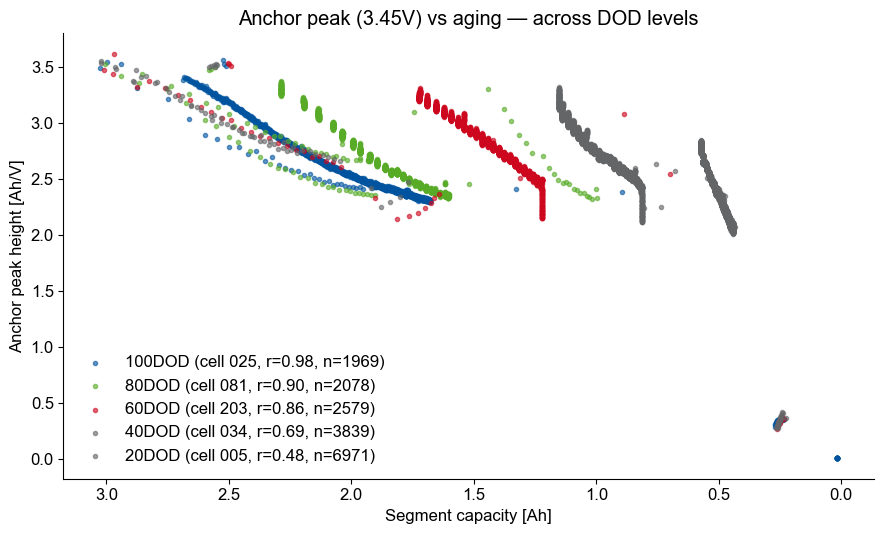

In [7]:
# ================================================================
# 多DOD对比: 每颗电池跑 峰高~容量 追踪, 汇总
# CELLS 按上一格侦察结果填: {'100DOD':'025', '60DOD':'0xx', '40DOD':'0xx', ...}
# ================================================================
CELLS={'100DOD':'025', '80DOD':'081', '60DOD':'203', '40DOD':'034', '20DOD':'005'}
PEAK_BAND=(3.35,3.55)           # 锚点峰区间(3.45V石墨峰)

def life_curves(cid, dod_label):
    base=f"{VTC}/METABatt_Sony_Murata_18650VTC6_{cid}"
    files=[f for f in sorted(fs.ls(base)) if f.endswith('.parquet')]
    out=[]
    for f in files:
        with fs.open(f) as fh:
            d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom']).to_pandas()
        d['Zeit']=TS(d['Zeit'])
        I=d['Strom'].values
        m=I<-1.0
        diff=np.diff(m.astype(int))
        st=np.where(diff==1)[0]+1; en=np.where(diff==-1)[0]+1
        if m[0]: st=np.r_[0,st]
        if m[-1]: en=np.r_[en,len(d)]
        for s,e in zip(st,en):
            if e-s<MIN_SEG: continue
            seg=d.iloc[s:e]; V=seg['Spannung'].values
            i0=np.argmax(V<V[0]-0.015)
            if i0>0 and e-s-i0>=MIN_SEG: seg=seg.iloc[i0:]; V=seg['Spannung'].values
            t=(seg['Zeit']-seg['Zeit'].iloc[0]).dt.total_seconds().values
            Q=np.cumsum(np.abs(seg['Strom'].values)*np.diff(t,prepend=t[0])/3600.0)
            o=np.argsort(V); Vu,idx=np.unique(V[o],return_index=True); Qu=Q[o][idx]
            vgrid=np.arange(Vu.min()+0.01,Vu.max()-0.01,DV_GRID)
            if len(vgrid)<50: continue
            Qsm=gaussian_filter1d(np.interp(vgrid,Vu,Qu),sigma=SIGMA)
            IC=np.abs(np.gradient(Qsm,vgrid))
            pm=(vgrid>=PEAK_BAND[0])&(vgrid<=PEAK_BAND[1])
            if pm.sum()<5: continue                       # 段没覆盖峰区→跳过
            out.append((Q[-1], IC[pm].max(), seg['Zeit'].iloc[0]))
    return out

fig,ax=plt.subplots(figsize=(9,5.5))
colors={'100DOD':'#00549F','80DOD':'#57AB27','60DOD':'#CC071E','40DOD':'#646567','20DOD':'#646567'}
for lbl,cid in CELLS.items():
    pts=life_curves(cid,lbl)
    if not pts: print(f"{lbl} cell {cid}: 无有效段(峰区未覆盖?)"); continue
    q=np.array([p[0] for p in pts]); h=np.array([p[1] for p in pts])
    r=np.corrcoef(q,h)[0,1] if len(q)>10 else np.nan
    ax.scatter(q,h,s=9,alpha=0.6,color=colors.get(lbl,'k'),
               label=f"{lbl} (cell {cid}, r={r:.2f}, n={len(q)})")
    print(f"{lbl} cell {cid}: {len(q)}段, 容量{q.min():.2f}~{q.max():.2f}Ah, r={r:.3f}")
ax.set_xlabel('Segment capacity [Ah]'); ax.set_ylabel('Anchor peak height [Ah/V]')
ax.set_title('Anchor peak (3.45V) vs aging — across DOD levels')
ax.legend(frameon=False); ax.invert_xaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.savefig('nca_dod_comparison.png',dpi=200,bbox_inches='tight')
plt.show()

In [8]:
# ---- 对每档: 按段容量分组重算r ----
# aging段: 容量在 [0.7, 1.3]×DOD名义容量 内; CU段: >2.5Ah
NOM = {'100DOD':3.0,'80DOD':2.4,'60DOD':1.8,'40DOD':1.2,'20DOD':0.6}
for lbl,cid in CELLS.items():
    pts=life_curves(cid,lbl)                # 或复用已存的pts
    q=np.array([p[0] for p in pts]); h=np.array([p[1] for p in pts])
    nom=NOM[lbl]
    m_aging=(q>0.7*nom)&(q<1.3*nom) if lbl!='100DOD' else q>2.0
    m_cu=q>2.5
    for tag,mm in [('aging段',m_aging),('CU满放',m_cu)]:
        if mm.sum()>30:
            # aging段内部没有容量作老化坐标 → 用时间序作代理: 段的先后顺序
            # 简化: 直接看 h 随样本序的趋势
            order=np.arange(mm.sum())
            r=np.corrcoef(order,h[mm][np.argsort(-q[mm]) if tag=='CU满放' else slice(None)])[0,1] \
              if tag=='CU满放' else np.corrcoef(order,h[mm])[0,1]
            print(f"{lbl} {tag}: n={mm.sum()}, r(峰高~时间序)={r:.3f}")

100DOD aging段: n=797, r(峰高~时间序)=-0.954
100DOD CU满放: n=92, r(峰高~时间序)=-0.477
80DOD aging段: n=1605, r(峰高~时间序)=-0.949
60DOD aging段: n=2201, r(峰高~时间序)=-0.994
40DOD aging段: n=3315, r(峰高~时间序)=-0.960
20DOD aging段: n=6926, r(峰高~时间序)=-0.980


In [9]:
# ---- 侦察: VTC capacity CSV 的结构 ----
CAP_VTC="projects/j8005-metabatt/Metabatt/VTC/40_capacity_monitore"
cfiles=fs.ls(CAP_VTC)
print(len(cfiles),"files, 示例:",cfiles[:3])

cap=pd.read_csv(f"s3://{CAP_VTC}/METABatt_Sony_Murata_18650VTC6_025_capacity.csv",
                storage_options=OPTS)          # 文件名格式若不同,按上面打印修正
print(cap.columns.tolist())
print(cap[['SOH','CAP_start_time']].dropna().head() if 'SOH' in cap.columns else cap.head())

409 files, 示例: ['projects/j8005-metabatt/Metabatt/VTC/40_capacity_monitore/METABatt_Sony_Murata_18650VTC6_003_capacity.csv', 'projects/j8005-metabatt/Metabatt/VTC/40_capacity_monitore/METABatt_Sony_Murata_18650VTC6_004_capacity.csv', 'projects/j8005-metabatt/Metabatt/VTC/40_capacity_monitore/METABatt_Sony_Murata_18650VTC6_005_capacity.csv']
['BM_Programm', 'Capacity_py', 'Ah_throughput', 'SOH', 'CAP_start_time']
    SOH                    CAP_start_time
0  95.8  2024-09-03 14:41:16.770000+00:00
1  91.6  2024-09-24 11:56:30.700000+00:00
2  88.8  2024-10-21 15:52:18.150000+00:00
3  86.6  2024-11-06 11:06:43.950000+00:00
4  84.9  2024-11-26 15:32:22.820000+00:00


In [10]:
# ---- 终审: 峰高 vs 官方SOH标签 ----
pts=life_curves(cid,lbl)
assert hasattr(pd.Timestamp(pts[0][2]),'year') and pd.Timestamp(pts[0][2]).year>2020, \
       f"第3元素不是时间戳: {pts[0][2]!r}"
def soh_interp_fn(cid):
    cap=pd.read_csv(f"s3://{CAP_VTC}/METABatt_Sony_Murata_18650VTC6_{cid}_capacity.csv",
                    storage_options=OPTS)
    s=cap.dropna(subset=['SOH']).copy()
    s['t']=TS(s['CAP_start_time']); s=s.sort_values('t')
    st=s['t'].values.astype('datetime64[s]').astype(np.float64)
    return lambda tsec: np.interp(tsec, st, s['SOH'].values), s['SOH'].min(), s['SOH'].max()

NOM={'100DOD':3.0,'80DOD':2.4,'60DOD':1.8,'40DOD':1.2,'20DOD':0.6}
for lbl,cid in CELLS.items():
    pts=life_curves(cid,lbl)                       # 需返回(容量,峰高,起始时间)版本
    q=np.array([p[0] for p in pts]); h=np.array([p[1] for p in pts])
    ts=np.array([pd.Timestamp(p[2]).value//10**9 for p in pts],dtype=float)
    f,slo,shi=soh_interp_fn(cid)
    nom=NOM[lbl]
    m=(q>0.7*nom)&(q<1.3*nom) if lbl!='100DOD' else q>2.0   # 只看aging段
    soh=f(ts[m])
    r=np.corrcoef(soh,h[m])[0,1]
    print(f"{lbl} cell {cid}: n={m.sum()}, r(峰高~SOH)={r:.3f}, 官方SOH {slo:.0f}~{shi:.0f}%")

100DOD cell 025: n=797, r(峰高~SOH)=0.977, 官方SOH 65~96%
80DOD cell 081: n=1605, r(峰高~SOH)=0.975, 官方SOH 64~96%
60DOD cell 203: n=2201, r(峰高~SOH)=0.996, 官方SOH 55~96%
40DOD cell 034: n=3315, r(峰高~SOH)=0.977, 官方SOH 59~96%
20DOD cell 005: n=6926, r(峰高~SOH)=0.993, 官方SOH 74~96%


In [11]:
def life_curves(cid, lbl):
    base=f"{VTC}/METABatt_Sony_Murata_18650VTC6_{cid}"
    files=[f for f in sorted(fs.ls(base)) if f.endswith('.parquet')]
    out=[]
    for f in files:
        with fs.open(f) as fh:
            d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom']).to_pandas()
        d['Zeit']=TS(d['Zeit'])
        I=d['Strom'].values
        m=I<-1.0
        diff=np.diff(m.astype(int))
        st=np.where(diff==1)[0]+1; en=np.where(diff==-1)[0]+1
        if m[0]: st=np.r_[0,st]
        if m[-1]: en=np.r_[en,len(d)]
        for s,e in zip(st,en):
            if e-s<MIN_SEG: continue
            seg=d.iloc[s:e]; V=seg['Spannung'].values
            i0=np.argmax(V<V[0]-0.015)
            if i0>0 and e-s-i0>=MIN_SEG:
                seg=seg.iloc[i0:]; V=seg['Spannung'].values
            t=(seg['Zeit']-seg['Zeit'].iloc[0]).dt.total_seconds().values
            Q=np.cumsum(np.abs(seg['Strom'].values)*np.diff(t,prepend=t[0])/3600.0)
            o=np.argsort(V); Vu,idx=np.unique(V[o],return_index=True); Qu=Q[o][idx]
            vgrid=np.arange(Vu.min()+0.01,Vu.max()-0.01,DV_GRID)
            if len(vgrid)<30: continue
            Qsm=gaussian_filter1d(np.interp(vgrid,Vu,Qu),sigma=SIGMA)
            IC=np.abs(np.gradient(Qsm,vgrid))
            pm=(vgrid>=3.35)&(vgrid<=3.55)
            if pm.sum()<5: continue
            out.append((Q[-1], IC[pm].max(), seg['Zeit'].iloc[0]))   # ← 时间戳在第3位
    return out

In [28]:
# ================ Block 0: 环境 + cell_curves ================
import re, numpy as np, pandas as pd, pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter1d
import s3fs
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY

OPTS={"key":S3_ACCESS_KEY,"secret":S3_SECRET_KEY,
      "client_kwargs":{"endpoint_url":"https://iseadocker.isea.rwth-aachen.de:9000","region_name":"us-east-1"},
      "config_kwargs":{"s3":{"addressing_style":"path"},"signature_version":"s3v4"}}
fs=s3fs.S3FileSystem(**OPTS)
TS=lambda s: pd.to_datetime(s,format='ISO8601')

VTC="projects/j8005-metabatt/Metabatt/VTC"
PRE="METABatt_Sony_Murata_18650VTC6_"
DV_GRID=0.002; SIGMA=2; MIN_SEG=10; I_TH=1.0; IR_DROP=0.015

def cell_curves(bid):
    """一颗电池全部放电段 → [dict(t0,cap,Vu,Qu,vgrid,IC)] 按时间排序"""
    out=[]
    for f in sorted(fs.ls(f"{VTC}/{PRE}{bid}")):
        if not f.endswith('.parquet'): continue
        with fs.open(f) as fh:
            d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom']).to_pandas()
        d['Zeit']=TS(d['Zeit']); I=d['Strom'].values
        m=I<-I_TH; diff=np.diff(m.astype(int))
        st=np.where(diff==1)[0]+1; en=np.where(diff==-1)[0]+1
        if m[0]: st=np.r_[0,st]
        if m[-1]: en=np.r_[en,len(d)]
        for s,e in zip(st,en):
            if e-s<MIN_SEG: continue
            seg=d.iloc[s:e]; V=seg['Spannung'].values
            i0=np.argmax(V<V[0]-IR_DROP)
            if i0>0 and e-s-i0>=MIN_SEG: seg=seg.iloc[i0:]; V=seg['Spannung'].values
            t=(seg['Zeit']-seg['Zeit'].iloc[0]).dt.total_seconds().values
            Q=np.cumsum(np.abs(seg['Strom'].values)*np.diff(t,prepend=t[0])/3600.0)
            o=np.argsort(V); Vu,idx=np.unique(V[o],return_index=True); Qu=Q[o][idx]
            vg=np.arange(Vu.min()+0.01,Vu.max()-0.01,DV_GRID)
            if len(vg)<30: continue
            IC=np.abs(np.gradient(gaussian_filter1d(np.interp(vg,Vu,Qu),SIGMA),vg))
            out.append(dict(t0=seg['Zeit'].iloc[0],cap=float(Q[-1]),Vu=Vu,Qu=Qu,vgrid=vg,IC=IC))
    out.sort(key=lambda c:c['t0'])
    return out

print("Block 0 ready")

Block 0 ready


In [33]:
# ================ Block 1: SOC×DOD 网格选格 ================
# 已验证主线(50SOC) + 偏心SOC对照组。对照组ID按你之前侦察输出填。
CELLS = {
    # bid : (SOC%, DOD%)
    "025": (50, 100),
    "108": (50,  80),
    "203": (50,  60),
    "034": (50,  40),
    "033": (50,  20),
    "008": (10,  20),      # 最早看过的那颗: 10SOC_20DOD → 预期不覆盖峰
    # "0xx": (90, 20),     # ← 从侦察结果补 90SOC_20DOD
    # "0xx": (30, 60),     # ← 可选: 再补1-2个中间格
}
NOM_AH = 3.0
BANDS = {
    "graphite 3.35-3.55": (3.35, 3.55),
    "low 2.90-3.20":      (2.90, 3.20),   # 新增，覆盖20%DOD
    "mid 3.55-3.70":      (3.55, 3.70),
    "cathode 3.72-3.90":  (3.72, 3.90),
}
PK_LO, PK_HI = 3.35, 3.55

In [34]:
# ================ Block 2: 覆盖判定 + 三带打分 + 自动推荐最佳峰 ================
rows = []
ic_store = {}
best_peak_record = {}  # 存储每个电池的最佳峰名称和r值

for bid, (soc, dod) in CELLS.items():
    cs = cell_curves(bid)
    nom = NOM_AH * dod / 100
    aging = [c for c in cs if 0.7*nom < c['cap'] < 1.3*nom]
    if dod == 100:
        aging = [c for c in cs if c['cap'] > 2.0]
    if len(aging) < 30:
        rows.append((bid, soc, dod, "-", "-", "样本不足", "None"))
        continue

    vlo = np.median([c['vgrid'].min() for c in aging])
    vhi = np.median([c['vgrid'].max() for c in aging])
    covers = (vlo < PK_LO) and (vhi > PK_HI)
    ic_store[bid] = (aging, covers)

    if not covers:
        rows.append((bid, soc, dod, f"{vlo:.2f}-{vhi:.2f}V", "否", "仅CU可提取", "None"))
        continue

    rs = {}
    order = np.arange(len(aging))
    for name, (lo, hi) in BANDS.items():
        hs = []
        for c in aging:
            mask = (c['vgrid'] >= lo) & (c['vgrid'] <= hi)
            if mask.any():
                hs.append(c['IC'][mask].max())
            else:
                hs.append(np.nan)
        valid = ~np.isnan(hs)
        if valid.sum() < 2:
            rs[name] = np.nan
        else:
            rs[name] = np.corrcoef(order[valid], np.array(hs)[valid])[0, 1]
    
    # 选出绝对值最大的相关系数（即随老化单调性最强的峰）
    best_name = max(rs, key=lambda k: abs(rs[k]) if not np.isnan(rs[k]) else -1)
    best_r = rs[best_name]
    best_peak_record[bid] = (best_name, best_r)

    rows.append((bid, soc, dod, f"{vlo:.2f}-{vhi:.2f}V", "是",
                 " | ".join(f"{k.split()[0]} r={v:+.2f}" if not np.isnan(v) else f"{k.split()[0]} r=nan" for k, v in rs.items()),
                 f"★推荐: {best_name} (|r|={abs(best_r):.2f})"))

print(f"{'cell':<6}{'SOC':<5}{'DOD':<5}{'电压范围':<14}{'覆盖':<6}三带相关系数{'':>30}推荐最佳峰")
print("-" * 110)
for r in rows:
    print(f"{r[0]:<6}{r[1]:<5}{r[2]:<5}{r[3]:<14}{r[4]:<6}{r[5]:<50}{r[6]}")

cell  SOC  DOD  电压范围          覆盖    三带相关系数                              推荐最佳峰
--------------------------------------------------------------------------------------------------------------
025   50   100  2.51-4.04V    是     graphite r=-0.95 | low r=-0.93 | mid r=-0.73 | cathode r=-0.48★推荐: graphite 3.35-3.55 (|r|=0.95)
108   50   80   2.51-4.01V    是     graphite r=-0.95 | low r=-0.95 | mid r=-0.64 | cathode r=-0.83★推荐: graphite 3.35-3.55 (|r|=0.95)
203   50   60   2.58-3.83V    是     graphite r=-0.99 | low r=-0.98 | mid r=-0.89 | cathode r=-0.87★推荐: graphite 3.35-3.55 (|r|=0.99)
034   50   40   2.66-3.71V    是     graphite r=-0.96 | low r=-0.99 | mid r=-0.94 | cathode r=+0.83★推荐: low 2.90-3.20 (|r|=0.99)
033   50   20   2.84-3.53V    否     仅CU可提取                                            None
008   10   20   2.51-3.50V    否     仅CU可提取                                            None


C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3324285395.py:14: UserWarning: Glyph 35206 (\N{CJK UNIFIED IDEOGRAPH-8986}) missing from font(s) Arial.
  plt.tight_layout(); plt.savefig('part1_soc_dod_grid.png', dpi=180); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3324285395.py:14: UserWarning: Glyph 30422 (\N{CJK UNIFIED IDEOGRAPH-76D6}) missing from font(s) Arial.
  plt.tight_layout(); plt.savefig('part1_soc_dod_grid.png', dpi=180); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3324285395.py:14: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(); plt.savefig('part1_soc_dod_grid.png', dpi=180); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3324285395.py:14: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) Arial.
  plt.tight_layout(); plt.savefig('part1_soc_dod_grid.png', dpi=180); plt.show()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3324285395.py:14

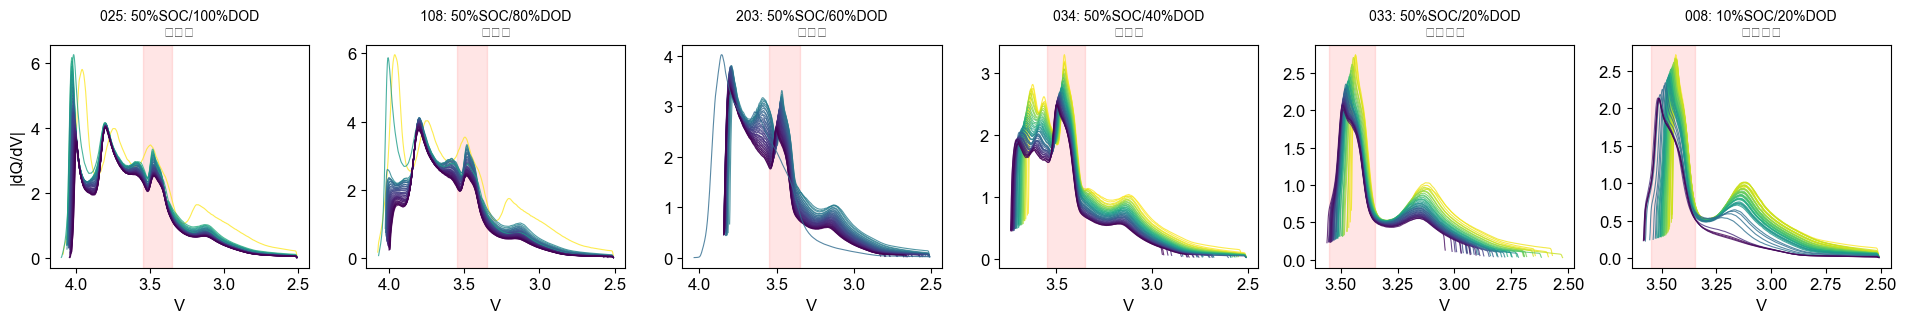

In [35]:
# ================ Block 3: 小图阵 —— 每颗电池的全寿命IC(汇报用) ================
n = len(ic_store)
fig, axes = plt.subplots(1, n, figsize=(3.2*n, 3.4), sharey=False)
for ax, (bid, (aging, covers)) in zip(np.atleast_1d(axes), ic_store.items()):
    soc, dod = CELLS[bid]
    caps = [c['cap'] for c in aging]
    norm = Normalize(min(caps), max(caps))
    for c in aging[::max(1, len(aging)//40)]:
        ax.plot(c['vgrid'], c['IC'], color=cm.viridis(norm(c['cap'])), lw=0.8, alpha=0.8)
    ax.axvspan(PK_LO, PK_HI, color='red', alpha=0.10)      # 锚点带
    ax.set_title(f"{bid}: {soc}%SOC/{dod}%DOD\n{'覆盖✓' if covers else '不覆盖✗'}", fontsize=10)
    ax.set_xlabel('V'); ax.invert_xaxis()
axes[0].set_ylabel('|dQ/dV|') if n > 1 else None
plt.tight_layout(); plt.savefig('part1_soc_dod_grid.png', dpi=180); plt.show()

C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3886802984.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(lo, hi, color='lime', alpha=0.2, edgecolor='green', linewidth=2, linestyle='--')
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3886802984.py:72: UserWarning: Glyph 35206 (\N{CJK UNIFIED IDEOGRAPH-8986}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3886802984.py:72: UserWarning: Glyph 30422 (\N{CJK UNIFIED IDEOGRAPH-76D6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3886802984.py:72: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3886802984.py:72: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\zho-xli\AppData\Local\Temp\ipykernel_17620\3886802984.py

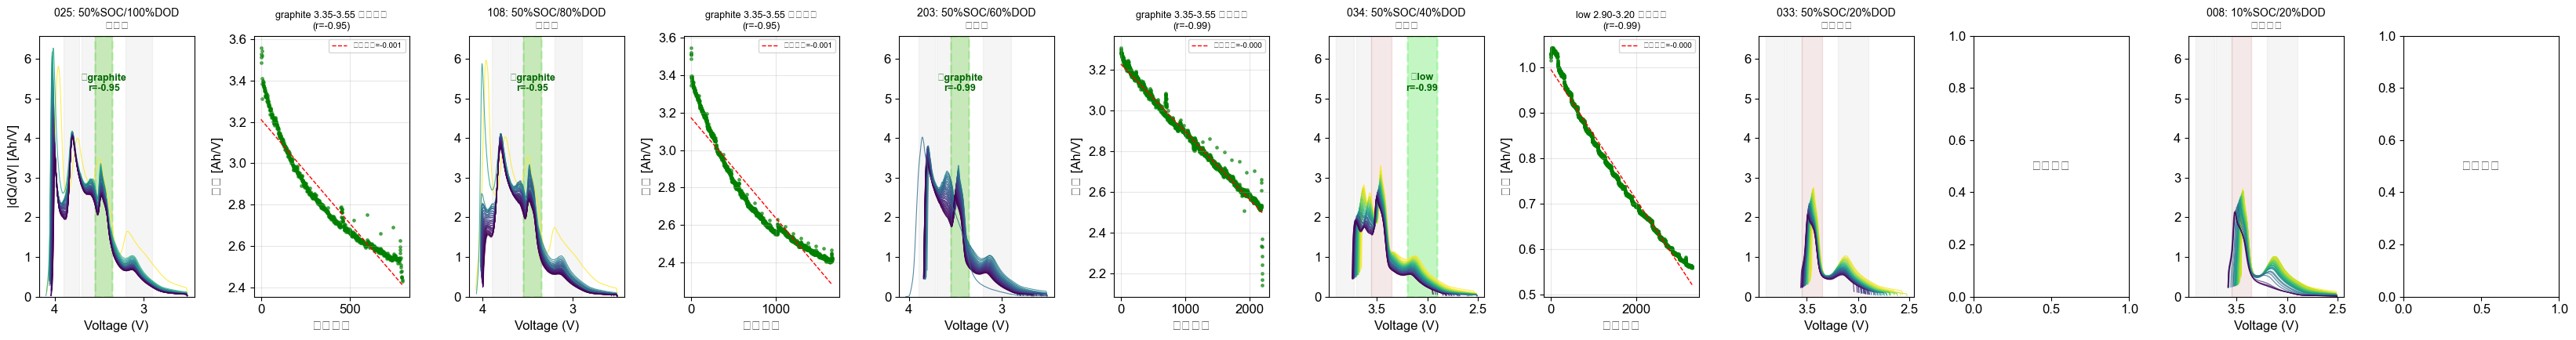

In [36]:
# ================ Block 3: 全寿命IC + 最佳峰高追踪 ================
n = len(ic_store)
fig = plt.figure(figsize=(5.5*n, 4.5))  # 调整宽度以适应双图并排

# 先计算全局最大IC值，用于统一纵坐标
global_max_ic = 0
for bid, (aging, covers) in ic_store.items():
    for c in aging[::max(1, len(aging)//40)]:
        global_max_ic = max(global_max_ic, c['IC'].max())

for idx, (bid, (aging, covers)) in enumerate(ic_store.items()):
    soc, dod = CELLS[bid]
    caps = [c['cap'] for c in aging]
    norm = Normalize(min(caps), max(caps))
    
    # ---- 左侧子图：全寿命IC叠加 ----
    ax1 = plt.subplot(1, n*2, 2*idx+1)   # 每个电池占两列，左图
    for c in aging[::max(1, len(aging)//40)]:
        ax1.plot(c['vgrid'], c['IC'], color=cm.viridis(norm(c['cap'])), lw=0.8, alpha=0.8)
    # 标记所有候选峰区（浅灰）
    for (lo, hi) in BANDS.values():
        ax1.axvspan(lo, hi, color='gray', alpha=0.08)
    # 高亮推荐的最佳峰区（绿色）
    if bid in best_peak_record:
        best_name, best_r = best_peak_record[bid]
        lo, hi = BANDS[best_name]
        ax1.axvspan(lo, hi, color='lime', alpha=0.2, edgecolor='green', linewidth=2, linestyle='--')
        ax1.text((lo+hi)/2, global_max_ic*0.9, f'★{best_name.split()[0]}\nr={best_r:.2f}',
                 ha='center', va='top', fontsize=9, color='darkgreen', weight='bold')
    # 红色锚点带（可选，如果不需要可删除）
    ax1.axvspan(PK_LO, PK_HI, color='red', alpha=0.05)
    ax1.set_title(f"{bid}: {soc}%SOC/{dod}%DOD\n{'覆盖✓' if covers else '不覆盖✗'}", fontsize=10)
    ax1.set_xlabel('Voltage (V)')
    ax1.invert_xaxis()
    ax1.set_ylim(0, global_max_ic * 1.05)   # 统一纵坐标
    if idx == 0:
        ax1.set_ylabel('|dQ/dV| [Ah/V]')
    
    # ---- 右侧子图：推荐峰的峰高随循环变化（验证单调性） ----
    ax2 = plt.subplot(1, n*2, 2*idx+2)
    if bid in best_peak_record:
        best_name, best_r = best_peak_record[bid]
        lo, hi = BANDS[best_name]
        # 提取每个循环的峰高
        hs = []
        for c in aging:
            mask = (c['vgrid'] >= lo) & (c['vgrid'] <= hi)
            if mask.any():
                hs.append(c['IC'][mask].max())
            else:
                hs.append(np.nan)
        # 过滤掉nan
        valid = ~np.isnan(hs)
        if valid.sum() > 1:
            x_plot = np.arange(len(hs))[valid]
            y_plot = np.array(hs)[valid]
            ax2.scatter(x_plot, y_plot, s=6, alpha=0.6, color='green')
            # 线性拟合
            coeffs = np.polyfit(x_plot, y_plot, 1)
            poly = np.poly1d(coeffs)
            ax2.plot(x_plot, poly(x_plot), 'r--', lw=1, label=f'趋势斜率={coeffs[0]:.3f}')
            ax2.set_title(f'{best_name} 峰高追踪\n(r={best_r:.2f})', fontsize=9)
            ax2.set_xlabel('循环序号')
            ax2.set_ylabel('峰高 [Ah/V]')
            ax2.legend(fontsize=7)
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, '数据不足', ha='center', va='center', transform=ax2.transAxes)
    else:
        ax2.text(0.5, 0.5, '无推荐峰', ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.savefig('part1_soc_dod_grid_with_tracking.png', dpi=200)
plt.show()